<a href="https://colab.research.google.com/github/aidakamalova-dev/olist-customer-satisfaction/blob/main/olist_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Блок 1. База данных и SQL**

In [1]:
# Устанавливаем библиотеку kagglehub
!pip install kagglehub -q

import kagglehub
import pandas as pd
import sqlite3
import os
import glob

In [2]:
# 1. Скачиваем датасет
print("Начинаю скачивание датасета...")
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print(f"Данные успешно скачаны в папку: {path}\n")

Начинаю скачивание датасета...
Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Данные успешно скачаны в папку: /kaggle/input/brazilian-ecommerce



In [3]:
# 2. Создаем базу данных SQLite и подключаемся к ней
db_path = 'olist.db'
conn = sqlite3.connect(db_path)
print("База данных olist.db создана.\n")

База данных olist.db создана.



In [4]:
# 3. Находим все CSV-файлы в скачанной папке
csv_files = glob.glob(os.path.join(path, "*.csv"))

In [6]:
# 4. В цикле читаем каждый CSV и загружаем его как таблицу в SQLite
print("Начинаю загрузку таблиц в базу данных...")
for file_path in csv_files:
    # Получаем имя файла без расширения
    table_name = os.path.basename(file_path).replace('.csv', '')

    # Читаем CSV с помощью pandas
    df = pd.read_csv(file_path)

    # Записываем датафрейм в таблицу SQLite
    df.to_sql(table_name, conn, if_exists='replace', index=False)

    print(f"✅ Таблица {table_name} загружена (строк: {len(df)})")

Начинаю загрузку таблиц в базу данных...
✅ Таблица olist_customers_dataset загружена (строк: 99441)
✅ Таблица olist_sellers_dataset загружена (строк: 3095)
✅ Таблица olist_order_reviews_dataset загружена (строк: 99224)
✅ Таблица olist_order_items_dataset загружена (строк: 112650)
✅ Таблица olist_products_dataset загружена (строк: 32951)
✅ Таблица olist_geolocation_dataset загружена (строк: 1000163)
✅ Таблица product_category_name_translation загружена (строк: 71)
✅ Таблица olist_orders_dataset загружена (строк: 99441)
✅ Таблица olist_order_payments_dataset загружена (строк: 103886)


In [7]:
# 5. Проверяем, какие таблицы появились в базе
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

print("\nСписок таблиц, доступных теперь в твоей БД:")
for table in tables:
    print(f"- {table[0]}")


Список таблиц, доступных теперь в твоей БД:
- olist_customers_dataset
- olist_sellers_dataset
- olist_order_reviews_dataset
- olist_order_items_dataset
- olist_products_dataset
- olist_geolocation_dataset
- product_category_name_translation
- olist_orders_dataset
- olist_order_payments_dataset


In [8]:
# Закрываем соединение с базой на всякий случай
conn.close()

In [9]:
import sqlite3
import pandas as pd

# Подключаемся к базе SQLite
conn = sqlite3.connect('olist.db')

# SQL-запрос для объединения таблиц и расчета первичных признаков
query = """
SELECT
    o.order_id,
    o.customer_id,
    r.review_score,

    -- Сроки доставки в днях (ключевой бизнес-фактор)
    ROUND(julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp), 2) AS delivery_time_days,
    ROUND(julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date), 2) AS delivery_delay_days,

    -- Агрегированные метрики по товарам в заказе
    i.total_items,
    i.total_price,
    i.total_freight,

    -- Агрегированные метрики по платежам
    p.total_payment_value,
    p.max_installments,

    -- Характеристики первого/основного товара
    pr.product_category_name,
    pr.product_weight_g

FROM olist_orders_dataset o

-- Присоединяем отзывы (наша целевая переменная)
INNER JOIN olist_order_reviews_dataset r
    ON o.order_id = r.order_id

-- Присоединяем агрегированные товарные позиции
LEFT JOIN (
    SELECT
        order_id,
        COUNT(order_item_id) AS total_items,
        SUM(price) AS total_price,
        SUM(freight_value) AS total_freight,
        MIN(product_id) AS main_product_id
    FROM olist_order_items_dataset
    GROUP BY order_id
) i ON o.order_id = i.order_id

-- Присоединяем агрегированные платежи
LEFT JOIN (
    SELECT
        order_id,
        SUM(payment_value) AS total_payment_value,
        MAX(payment_installments) AS max_installments
    FROM olist_order_payments_dataset
    GROUP BY order_id
) p ON o.order_id = p.order_id

-- Присоединяем параметры товара
LEFT JOIN olist_products_dataset pr
    ON i.main_product_id = pr.product_id

WHERE o.order_status = 'delivered'
  AND o.order_delivered_customer_date IS NOT NULL;
"""

# Загружаем результат SQL-запроса в pandas DataFrame
df_features = pd.read_sql_query(query, conn)

# Закрываем соединение с БД
conn.close()

# Выводим информацию и первые 5 строк полученной витрины
print(f"Витрина успешно собрана! Размер: {df_features.shape[0]} строк, {df_features.shape[1]} колонок.\n")
print(df_features.head())

Витрина успешно собрана! Размер: 96353 строк, 12 колонок.

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

   review_score  delivery_time_days  delivery_delay_days  total_items  \
0             4                8.44                -7.11            1   
1             4               13.78                -5.36            1   
2             5                9.39               -17.25            1   
3             5               13.21               -12.98            1   
4             5                2.87                -9.24            1   

   total_price  total_freight  total_payment_value  max_install

## **Блок 2. Разведочный анализ данных (EDA)**

=== Пропущенные значения по колонкам ===
order_id                    0
customer_id                 0
review_score                0
delivery_time_days          0
delivery_delay_days         0
total_items                 0
total_price                 0
total_freight               0
total_payment_value         1
max_installments            1
product_category_name    1360
product_weight_g           16
is_dissatisfied             0
dtype: int64




/tmp/ipykernel_1726/189639287.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_features, x='review_score', palette='Blues_r')
/tmp/ipykernel_1726/189639287.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_features, x='is_dissatisfied', palette='Set2')


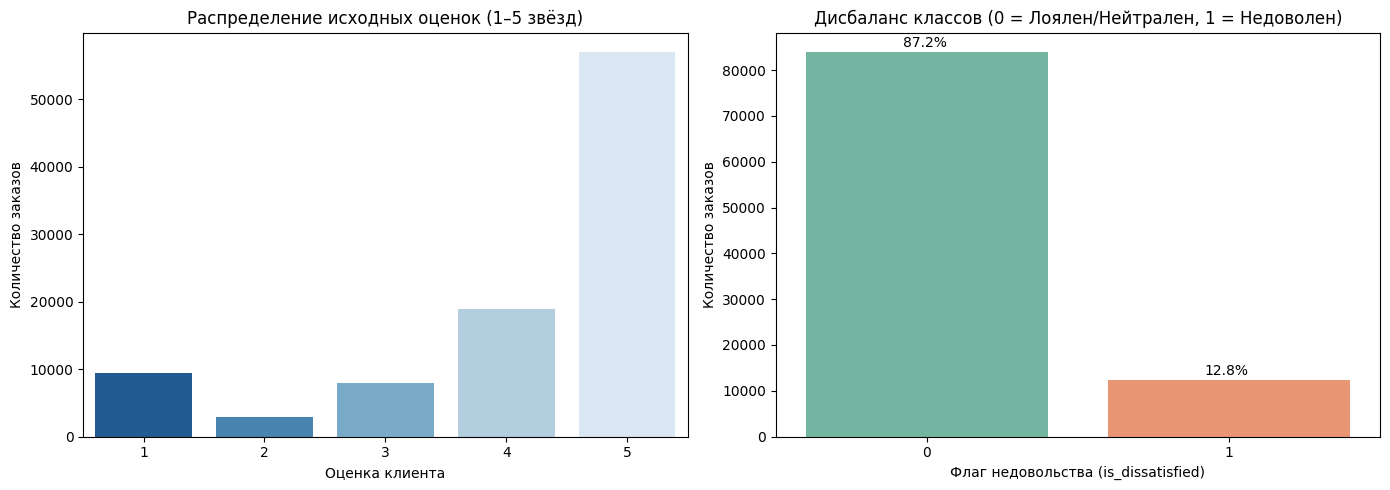

Доля негативных оценок (класс 1): 12.81%
Доля остальных оценок (класс 0): 87.19%


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Создаем бинарную целевую переменную (1 - низкая оценка 1-2 звезды, 0 - остальные)
df_features['is_dissatisfied'] = df_features['review_score'].apply(lambda x: 1 if x <= 2 else 0)

# 2. Проверяем пропуски в данных
print("=== Пропущенные значения по колонкам ===")
print(df_features.isnull().sum())
print("\n" + "="*40 + "\n")

# 3. Анализ дисбаланса классов
plt.figure(figsize=(14, 5))

# График 1: Распределение исходных оценок
plt.subplot(1, 2, 1)
sns.countplot(data=df_features, x='review_score', palette='Blues_r')
plt.title('Распределение исходных оценок (1–5 звёзд)')
plt.xlabel('Оценка клиента')
plt.ylabel('Количество заказов')

# График 2: Дисбаланс бинарной целевой переменной
plt.subplot(1, 2, 2)
ax = sns.countplot(data=df_features, x='is_dissatisfied', palette='Set2')
plt.title('Дисбаланс классов (0 = Лоялен/Нейтрален, 1 = Недоволен)')
plt.xlabel('Флаг недовольства (is_dissatisfied)')
plt.ylabel('Количество заказов')

# Добавляем проценты над барами
total = len(df_features)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.08
    y = p.get_height() + 1000
    ax.annotate(percentage, (x, y))

plt.tight_layout()
plt.show()

# Выводим точно процент дисбаланса
dissatisfied_share = df_features['is_dissatisfied'].mean() * 100
print(f"Доля негативных оценок (класс 1): {dissatisfied_share:.2f}%")
print(f"Доля остальных оценок (класс 0): {100 - dissatisfied_share:.2f}%")

/tmp/ipykernel_1726/3780709816.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=filtered_df, x='is_dissatisfied', y='delivery_delay_days', palette='Set2')


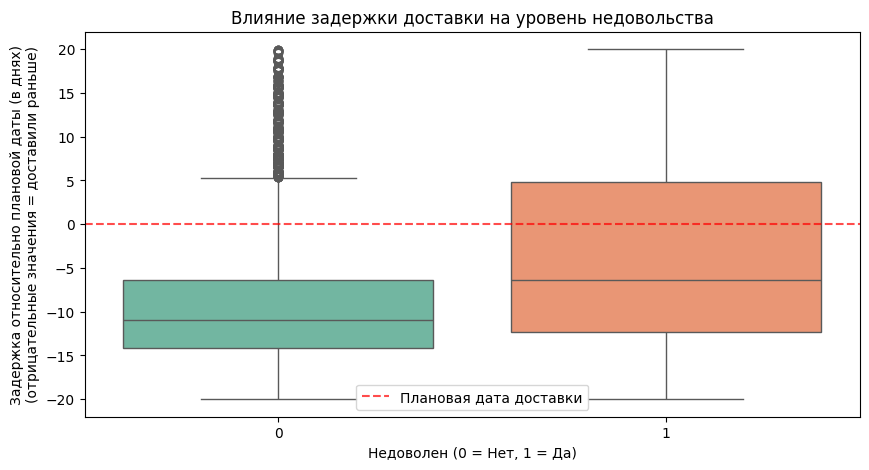

In [11]:
plt.figure(figsize=(10, 5))

# Фильтруем крайние выбросы для наглядности графика (задержки от -20 до +20 дней)
filtered_df = df_features[(df_features['delivery_delay_days'] >= -20) & (df_features['delivery_delay_days'] <= 20)]

sns.boxplot(data=filtered_df, x='is_dissatisfied', y='delivery_delay_days', palette='Set2')
plt.title('Влияние задержки доставки на уровень недовольства')
plt.xlabel('Недоволен (0 = Нет, 1 = Да)')
plt.ylabel('Задержка относительно плановой даты (в днях)\n(отрицательные значения = доставили раньше)')
plt.axhline(0, color='red', linestyle='--', alpha=0.7, label='Плановая дата доставки')
plt.legend()
plt.show()

Вывод:

Дисбаланс классов (12.81% негативных оценок):

Только ~12.8% клиентов ставят оценку 1–2 звезды. Это сильный дисбаланс классов.   

Бизнес-вывод для ML: Использовать метрику Accuracy нельзя — модель, просто угадывающая всегда «0», даст 87.2% точности, но не найдет ни одного недовольного клиента. Нужно ориентироваться на PR-AUC, F1-Score или Recall для класса 1.   

Влияние задержки доставки (delivery_delay_days):

Для довольных клиентов (0) медианная доставка происходит примерно на 11 дней раньше заложенного срока.   Для недовольных клиентов (1) доставка задерживается гораздо чаще — медиана сдвинута ближе к 0, а значительная часть заказов доставляется строго после плановой даты.   

Бизнес-вывод: Сроки доставки — один из ключевых триггеров негатива.   

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# 1. Отбираем признаки для модели (исключаем ID и исходную оценку review_score)
feature_cols = [
    'delivery_time_days',
    'delivery_delay_days',
    'total_items',
    'total_price',
    'total_freight',
    'total_payment_value',
    'max_installments',
    'product_category_name',
    'product_weight_g'
]

X = df_features[feature_cols]
y = df_features['is_dissatisfied']

In [13]:
# 2. Делим выборку на train и test (80/20) с сохранением пропорций классов (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [14]:
# 3. Выделяем числовые и категориальные признаки
num_features = [
    'delivery_time_days', 'delivery_delay_days', 'total_items',
    'total_price', 'total_freight', 'total_payment_value',
    'max_installments', 'product_weight_g'
]
cat_features = ['product_category_name']

# Пайплайн для числовых признаков: заполнение медианой + масштабирование
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Пайплайн для категориальных признаков: заполнение 'unknown' + OneHotEncoder
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Объединяем обработку
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# Подготавливаем данные
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

print(f"Данные успешно подготовлены!")
print(f"Размер обучающей выборки: {X_train_prep.shape}")
print(f"Размер тестовой выборки: {X_test_prep.shape}")

Данные успешно подготовлены!
Размер обучающей выборки: (77082, 81)
Размер тестовой выборки: (19271, 81)


### **Блок 3. Подготовка данных и Машинное обучение**

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

print("Обучаем Логистическую регрессию...")
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_prep, y_train)

lr_pred = lr.predict(X_test_prep)
lr_probs = lr.predict_proba(X_test_prep)[:, 1]

print("\nОбучаем Случайный лес (Random Forest)...")
rf = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_prep, y_train)

rf_pred = rf.predict(X_test_prep)
rf_probs = rf.predict_proba(X_test_prep)[:, 1]

# Сравнение результатов
print("\n" + "="*40)
print("РЕЗУЛЬТАТЫ: ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ")
print("="*40)
print(classification_report(y_test, lr_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_probs):.4f}")

print("\n" + "="*40)
print("РЕЗУЛЬТАТЫ: СЛУЧАЙНЫЙ ЛЕС (Random Forest)")
print("="*40)
print(classification_report(y_test, rf_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_probs):.4f}")

Обучаем Логистическую регрессию...

Обучаем Случайный лес (Random Forest)...

РЕЗУЛЬТАТЫ: ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ
              precision    recall  f1-score   support

           0       0.93      0.78      0.84     16802
           1       0.28      0.59      0.38      2469

    accuracy                           0.75     19271
   macro avg       0.60      0.68      0.61     19271
weighted avg       0.84      0.75      0.78     19271

ROC-AUC Score: 0.7375

РЕЗУЛЬТАТЫ: СЛУЧАЙНЫЙ ЛЕС (Random Forest)
              precision    recall  f1-score   support

           0       0.93      0.88      0.90     16802
           1       0.40      0.52      0.45      2469

    accuracy                           0.84     19271
   macro avg       0.66      0.70      0.68     19271
weighted avg       0.86      0.84      0.85     19271

ROC-AUC Score: 0.7539


/tmp/ipykernel_1726/3166754059.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_features, x='Importance', y='Feature', palette='viridis')


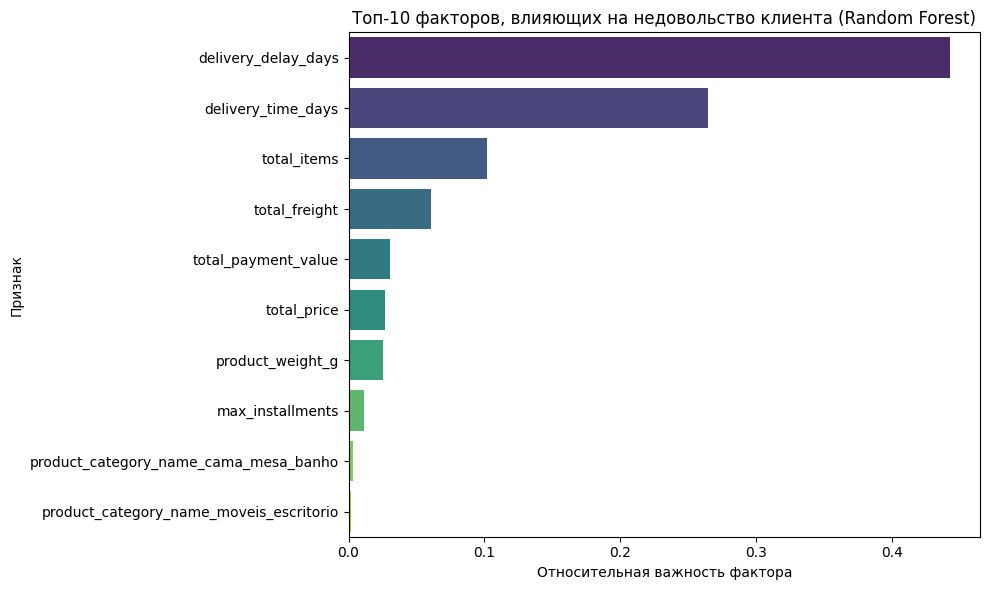

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# Получаем названия признаков из препроцессора
# Числовые идут первыми
feature_names = num_features.copy()

# Добавляем названия закодированных категориальных признаков
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(cat_features)
feature_names.extend(cat_feature_names)

# Извлекаем важность признаков из Random Forest
importances = rf.feature_importances_

# Создаем датафрейм для удобства
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Сортируем по убыванию важности и берем топ-10
top_10_features = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Рисуем график
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_features, x='Importance', y='Feature', palette='viridis')
plt.title('Топ-10 факторов, влияющих на недовольство клиента (Random Forest)')
plt.xlabel('Относительная важность фактора')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()